# Gaza — 4K damage tiles with UNOSAT footprints

4K (3840 × 2160 px) tiles at native 3 m resolution, pre-war and post-war, with
UNOSAT damage footprints drawn directly onto the image pixels using PIL —
no matplotlib, no clipping, no bbox issues.

| Item | Value |
|---|---|
| Planet raster | 11,431 × 13,589 px = 34.3 × 40.8 km |
| 4K tile | 3840 × 2160 px = 11.52 × 6.48 km = 74.6 km² |
| Grid | 3 cols × 7 rows = 21 tiles → **42 images** |

**Footprint colours (same on both pre and post)**

| Colour | Meaning |
|---|---|
| 🔴 Red | Fully destroyed in May 2024 (class 1–2) |
| 🟠 Orange | Partially damaged in May 2024 (class 3–4) |
| 🔵 Blue | Newly fully destroyed by July 2025 |
| 🟢 Green | Newly partially damaged by July 2025 |
| ⚪ Grey | Not destroyed in either assessment |

**Note on the western column:** tiles in column 0 cover the Mediterranean Sea —
zero UNOSAT points are expected there and those tiles will have no footprints.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q geopandas rasterio pillow

In [ ]:
import os, math, glob
import numpy as np
import geopandas as gpd
import rasterio
from PIL import Image, ImageDraw, ImageFont

BASE    = '/content/drive/MyDrive/Colab Notebooks/War_Damage'
PS_TIF  = f'{BASE}/rasters/gaza_20240503_ps_pre12m_forward1m_3m.tif'
JUL_GDB = f'{BASE}/UNOSAT_GazaStrip_CDA_08July2025.gdb'
OUT_DIR = '/content/tiles_4k'          # local SSD — fast writes, copy to Drive at the end
os.makedirs(OUT_DIR, exist_ok=True)

TILE_W, TILE_H = 3840, 2160
PIX_M          = 3
FULLY  = {1, 2}
PARTLY = {3, 4}
COL = {
    'grey':   '#808080',
    'red':    '#E74C3C',
    'orange': '#E67E22',
    'blue':   '#2980B9',
    'green':  '#27AE60',
}

with rasterio.open(PS_TIF) as src:
    RAS_H, RAS_W = src.height, src.width
    raster_crs   = src.crs
    inv_tf       = ~src.transform

n_cols = math.ceil(RAS_W / TILE_W)
n_rows = math.ceil(RAS_H / TILE_H)
print(f'Raster: {RAS_W}×{RAS_H} px = {RAS_W*PIX_M/1000:.1f}×{RAS_H*PIX_M/1000:.1f} km')
print(f'Grid  : {n_cols} cols × {n_rows} rows = {n_cols*n_rows} tiles → {n_cols*n_rows*2} images')

Raster: 11431×13589 px = 34.3×40.8 km
Grid  : 3 cols × 7 rows = 21 tiles → 42 images


In [ ]:
print('Loading UNOSAT …')
jul = gpd.read_file(JUL_GDB, layer='Damage_Sites_GazaStrip_20250708')

# compound 3D CRS — always go via EPSG:4326 to avoid silent mis-projection
jul = jul.to_crs('EPSG:4326').to_crs(raster_crs)

def grp(cls):
    if cls in FULLY:  return 'fully'
    if cls in PARTLY: return 'partly'
    return 'none'

jul['grp_may'] = jul['Main_Damage_Site_Class_7'].map(grp)
jul['grp_jul'] = jul['Main_Damage_Site_Class_13'].map(grp)

def colour(row):
    gm, gj = row['grp_may'], row['grp_jul']
    if gm == 'fully':  return 'red'
    if gm == 'partly': return 'orange'
    if gj == 'fully':  return 'blue'
    if gj == 'partly': return 'green'
    return 'grey'

jul['color_key'] = jul.apply(colour, axis=1)
jul['color']     = jul['color_key'].map(COL)

cx = jul.geometry.x.values
cy = jul.geometry.y.values
jul['px_col'] = np.round(inv_tf.a*cx + inv_tf.b*cy + inv_tf.c).astype(int)
jul['px_row'] = np.round(inv_tf.d*cx + inv_tf.e*cy + inv_tf.f).astype(int)

inside = ((jul.px_col>=0)&(jul.px_col<RAS_W)&(jul.px_row>=0)&(jul.px_row<RAS_H))
print(f'{inside.sum():,} of {len(jul):,} points inside raster')
for k,v in jul['color_key'].value_counts().items():
    labels = {'red':'May fully destroyed','orange':'May partially damaged',
              'blue':'Jul newly full','green':'Jul newly partial','grey':'no damage'}
    print(f'  {labels[k]:30s} {v:>8,}')

Loading UNOSAT …
192,848 of 192,851 points inside raster
  May partially damaged            81,124
  May fully destroyed              53,435
  Jul newly full                   40,419
  Jul newly partial                15,085
  no damage                         2,788


In [ ]:
# which tiles actually have data (col 0 = sea, always zero)
print('Points per tile:')
print(f'{"":10}', ''.join(f'  col {tc}' for tc in range(n_cols)))
for tr in range(n_rows):
    row_str = f'row {tr}     '
    for tc in range(n_cols):
        c0,r0=tc*TILE_W,tr*TILE_H; w=min(TILE_W,RAS_W-c0); h=min(TILE_H,RAS_H-r0)
        m=((jul.px_col>=c0)&(jul.px_col<c0+w)&(jul.px_row>=r0)&(jul.px_row<r0+h))
        n=m.sum(); row_str += f'  {n:>7,}' if n else '        —'
    print(row_str)

Points per tile:
             col 0  col 1  col 2
row 0             —    1,644   27,850
row 1             —   18,110   35,005
row 2             —   18,297      176
row 3         3,739    9,183        —
row 4        36,462   10,594        —
row 5        30,372    1,070        —
row 6           346        —        —


In [ ]:
def hex_to_rgb(h):
    h = h.lstrip('#')
    return tuple(int(h[i:i+2], 16) for i in (0,2,4))

def stretch(arr, pct=(1,99)):
    out = np.zeros((*arr.shape[1:],3), dtype=np.uint8)
    for k in range(3):
        ch = arr[k]; valid = ch[ch>0]
        lo,hi = (np.percentile(valid,pct) if valid.size else (0,1))
        out[...,k] = np.clip((ch-lo)/max(hi-lo,1e-6)*255, 0, 255)
    return out

def make_tile(tile_row, tile_col, period, dot_radius=5):
    """
    Generate one 4K PNG — everything drawn with PIL directly onto the
    pixel array, so what you see is exactly what gets saved to disk.
    RGB throughout: no RGBA, no matplotlib, no bbox clipping.
    """
    c0 = tile_col * TILE_W;  r0 = tile_row * TILE_H
    w  = min(TILE_W, RAS_W-c0);  h = min(TILE_H, RAS_H-r0)
    if w<=0 or h<=0: return None, 0

    # imagery
    bands = [3,2,1] if period=='pre' else [7,6,5]
    with rasterio.open(PS_TIF) as src:
        arr = src.read(bands, window=rasterio.windows.Window(c0,r0,w,h)).astype('float32')
    img  = Image.fromarray(stretch(arr), 'RGB')
    draw = ImageDraw.Draw(img)

    # footprint dots
    mask = ((jul.px_col>=c0)&(jul.px_col<c0+w)&
            (jul.px_row>=r0)&(jul.px_row<r0+h))
    sub  = jul[mask]; n_pts = len(sub)
    if n_pts:
        r = dot_radius
        for pc,pr,col in zip(sub.px_col.values-c0,
                              sub.px_row.values-r0,
                              sub.color.values):
            draw.ellipse([pc-r, pr-r, pc+r, pr+r], fill=hex_to_rgb(col))

    # text — solid RGB backgrounds only (no alpha on RGB image)
    try:
        fL = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf', 36)
        fS = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', 22)
    except:
        fL = fS = ImageFont.load_default()

    pl = 'PRE-WAR  (Oct 2022–Oct 2023)' if period=='pre' else 'POST-WAR  (Jun 2024)'
    draw.rectangle([20,20,760,75], fill=(0,0,0))
    draw.text((30,28), pl, fill=(255,255,255), font=fL)

    info = (f'Tile r{tile_row+1}c{tile_col+1}/{n_rows}×{n_cols} | '
            f'{w*PIX_M/1000:.2f}×{h*PIX_M/1000:.2f} km | {n_pts:,} pts | 3 m/px')
    draw.rectangle([20, h-45, min(len(info)*13, w-20), h-8], fill=(0,0,0))
    draw.text((30, h-40), info, fill=(255,255,255), font=fS)

    # legend
    items = [('red','May 2024 fully destroyed'),('orange','May 2024 partially damaged'),
             ('blue','Jul 2025 newly fully destroyed'),('green','Jul 2025 newly partial'),
             ('grey','Not destroyed either')]
    lx,ly = w-500,20
    draw.rectangle([lx-8,ly-4,w-8,ly+len(items)*34+4], fill=(0,0,0))
    for i,(ck,lbl) in enumerate(items):
        y=ly+i*34; rr=10
        draw.ellipse([lx,y+4,lx+2*rr,y+4+2*rr], fill=hex_to_rgb(COL[ck]))
        draw.text((lx+2*rr+8,y+4), lbl, fill=(255,255,255), font=fS)

    return img, n_pts

## Verify — checks one tile on screen and saves to Drive

Run this before the full loop to confirm footprints are visible.

Best tile: row=4 col=0 (36,462 points)


/tmp/ipykernel_1173/3862669781.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img  = Image.fromarray(stretch(arr), 'RGB')


Saved to Drive. Showing preview …


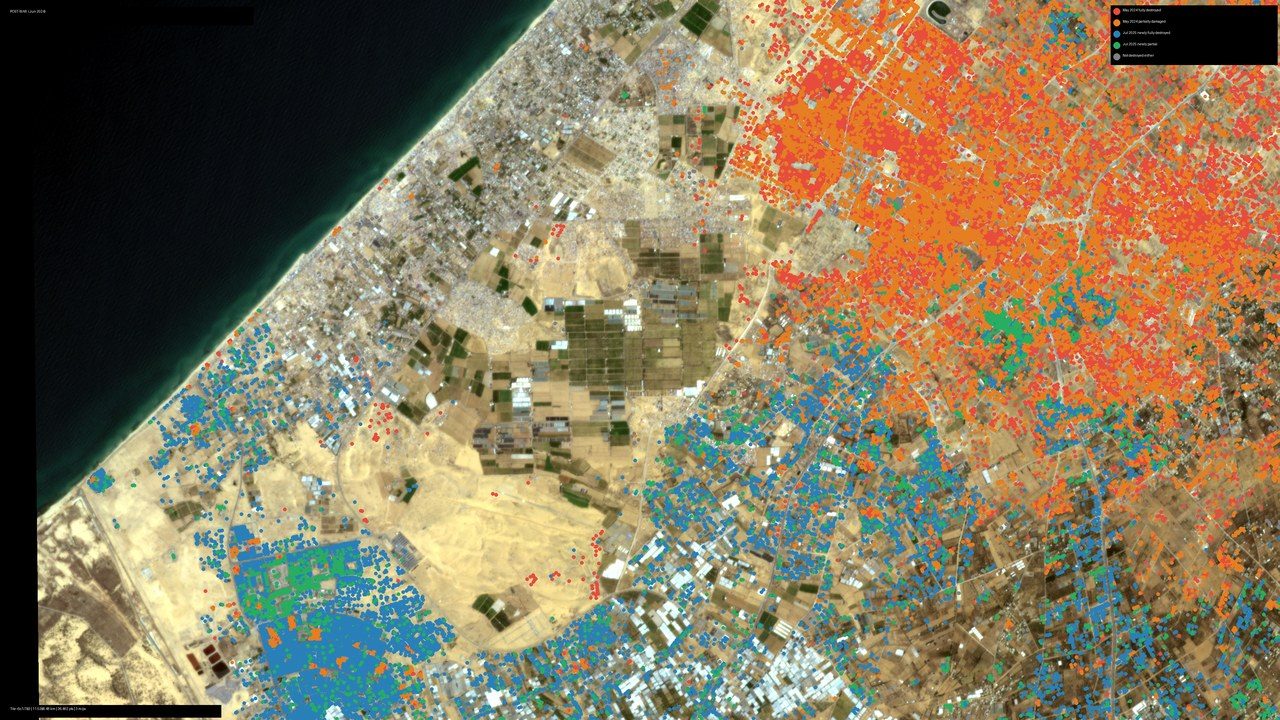

In [ ]:
# pick the tile with the most UNOSAT points
best_tr,best_tc,best_n=0,0,0
for tr in range(n_rows):
    for tc in range(n_cols):
        c0,r0=tc*TILE_W,tr*TILE_H; w=min(TILE_W,RAS_W-c0); h=min(TILE_H,RAS_H-r0)
        m=((jul.px_col>=c0)&(jul.px_col<c0+w)&(jul.px_row>=r0)&(jul.px_row<r0+h))
        if m.sum()>best_n: best_n=m.sum();best_tr=tr;best_tc=tc

print(f'Best tile: row={best_tr} col={best_tc} ({best_n:,} points)')
img, n = make_tile(best_tr, best_tc, 'post')
img.save(f'{BASE}/tiles_4k/verify_post.png')
print(f'Saved to Drive. Showing preview …')

from IPython.display import Image as IPImage
thumb = img.resize((1280,720), Image.LANCZOS)
thumb.save('/content/verify_thumb.jpg', quality=88)
IPImage('/content/verify_thumb.jpg')

## Generate all 42 tiles

Writes to local SSD (`/content/tiles_4k`) then copies to Drive at the end.
Local writes are ~10× faster than writing through the Drive FUSE mount.

In [ ]:
from IPython.display import clear_output

os.makedirs(OUT_DIR, exist_ok=True)
# clear local directory so we always regenerate fresh
for f in glob.glob(f'{OUT_DIR}/*.png'): os.remove(f)

total = n_rows * n_cols * 2; done = 0
for period in ('pre','post'):
    for tr in range(n_rows):
        for tc in range(n_cols):
            result = make_tile(tr, tc, period)
            done += 1
            pct = done/total
            bar = '█'*int(40*pct)+'░'*(40-int(40*pct))
            clear_output(wait=True)
            if result[0] is None:
                print(f'[{bar}] {done}/{total}  tile r{tr}c{tc} {period} — empty (sea)')
            else:
                img_tile, n_pts = result
                fname = f'{OUT_DIR}/tile_r{tr:02d}_c{tc:02d}_{period}.png'
                img_tile.save(fname)
                mb = os.path.getsize(fname)/1e6
                print(f'[{bar}] {done}/{total}  {os.path.basename(fname)} — {n_pts:,} pts {mb:.1f} MB')

files = glob.glob(f'{OUT_DIR}/*.png')
print(f'\n✓ {len(files)} tiles on local disk, '
      f'{sum(os.path.getsize(f) for f in files)/1e6:.0f} MB total')

[████████████████████████████████████████] 42/42  tile_r06_c02_post.png — 0 pts 3.0 MB

✓ 42 tiles on local disk, 485 MB total


## Copy to Drive and make overview JPEGs

In [ ]:
import shutil

DRIVE_TILES = f'{BASE}/tiles_4k'
os.makedirs(DRIVE_TILES, exist_ok=True)

print('Copying tiles to Drive …')
for f in sorted(glob.glob(f'{OUT_DIR}/*.png')):
    dst = f'{DRIVE_TILES}/{os.path.basename(f)}'
    shutil.copy(f, dst)
    print(f'  {os.path.basename(f)} → Drive')

print('\nGenerating side-by-side overview JPEGs …')
for tr in range(n_rows):
    for tc in range(n_cols):
        pf = f'{OUT_DIR}/tile_r{tr:02d}_c{tc:02d}_pre.png'
        qf = f'{OUT_DIR}/tile_r{tr:02d}_c{tc:02d}_post.png'
        if not (os.path.exists(pf) and os.path.exists(qf)): continue
        pre  = Image.open(pf).convert('RGB').resize((1920,1080), Image.LANCZOS)
        post = Image.open(qf).convert('RGB').resize((1920,1080), Image.LANCZOS)
        canvas = Image.new('RGB',(3840,1080),(0,0,0))
        canvas.paste(pre,(0,0)); canvas.paste(post,(1920,0))
        out = f'{DRIVE_TILES}/overview_r{tr:02d}_c{tc:02d}.jpg'
        canvas.save(out, quality=85)
        print(f'  overview_r{tr:02d}_c{tc:02d}.jpg  ({os.path.getsize(out)/1e6:.1f} MB)')
print('\nAll done. Open tiles_4k/ on Drive.')

Copying tiles to Drive …
  tile_r00_c00_post.png → Drive
  tile_r00_c00_pre.png → Drive
  tile_r00_c01_post.png → Drive
  tile_r00_c01_pre.png → Drive
  tile_r00_c02_post.png → Drive
  tile_r00_c02_pre.png → Drive
  tile_r01_c00_post.png → Drive
  tile_r01_c00_pre.png → Drive
  tile_r01_c01_post.png → Drive
  tile_r01_c01_pre.png → Drive
  tile_r01_c02_post.png → Drive
  tile_r01_c02_pre.png → Drive
  tile_r02_c00_post.png → Drive
  tile_r02_c00_pre.png → Drive
  tile_r02_c01_post.png → Drive
  tile_r02_c01_pre.png → Drive
  tile_r02_c02_post.png → Drive
  tile_r02_c02_pre.png → Drive
  tile_r03_c00_post.png → Drive
  tile_r03_c00_pre.png → Drive
  tile_r03_c01_post.png → Drive
  tile_r03_c01_pre.png → Drive
  tile_r03_c02_post.png → Drive
  tile_r03_c02_pre.png → Drive
  tile_r04_c00_post.png → Drive
  tile_r04_c00_pre.png → Drive
  tile_r04_c01_post.png → Drive
  tile_r04_c01_pre.png → Drive
  tile_r04_c02_post.png → Drive
  tile_r04_c02_pre.png → Drive
  tile_r05_c00_post.png → Driv

In [ ]:

import os, glob
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


BASE        = '/content/drive/MyDrive/Colab Notebooks/War_Damage'
DATASET_DIR = f'{BASE}/datasets'
JUL_GDB     = f'{BASE}/UNOSAT_GazaStrip_CDA_08July2025.gdb'

N_PER_CAT = 10
SEED      = 42
PCT       = (1, 99)

PRE_IDX  = [2, 1, 0]   # ps_pre_R/G/B  (channel positions in .npz)
POST_IDX = [6, 5, 4]   # ps_post_R/G/B

CATS = [
    ('destroyed',  'Destroyed\n(class 1)',          '#C0392B'),
    ('severely',   'Severely Damaged\n(class 2)',    '#E74C3C'),
    ('moderately', 'Moderately Damaged\n(class 3)',  '#E67E22'),
    ('possibly',   'Possibly Damaged\n(class 4)',    '#F1C40F'),
    ('no_damage',  'No Visible Damage\n(class 11)',  '#95A5A6'),
]

def assign_cat(cls_val):
    if pd.isna(cls_val): return None
    c = int(cls_val)
    if c == 1:       return 'destroyed'
    if c == 2:       return 'severely'
    if c == 3:       return 'moderately'
    if c == 4:       return 'possibly'
    if c in {11, 6}: return 'no_damage'
    return None

# ── load dataset ──────────────────────────────────────────────────────────────
files = sorted(glob.glob(f'{DATASET_DIR}/Gaza_*.npz'))
assert files, f'No .npz in {DATASET_DIR}'
z    = np.load(files[-1], allow_pickle=False)
X    = z['X'].astype('float32')
print(f'Loaded {os.path.basename(files[-1])}: {len(X):,} patches')

parquet = files[-1].replace('.npz', '.parquet')
gdf = gpd.read_parquet(parquet).reset_index(drop=True)
print(f'Parquet: {len(gdf):,} rows | CRS: {gdf.crs}')
assert len(gdf) == len(X), f'Parquet rows ({len(gdf)}) ≠ X patches ({len(X)})'

# ── load UNOSAT multi-class labels ───────────────────────────────────────────
print('Loading UNOSAT …')
jul = gpd.read_file(JUL_GDB, layer='Damage_Sites_GazaStrip_20250708',
                    columns=['geometry', 'Main_Damage_Site_Class_13'])

# reproject both to metres for the spatial join
# compound CRS in jul — go via 4326 first
gdf_m = gdf.set_crs('EPSG:4326', allow_override=True).to_crs('EPSG:32636')
jul_m = jul.to_crs('EPSG:4326').to_crs('EPSG:32636')

# sjoin_nearest without max_distance so every patch gets its nearest point
joined = gpd.sjoin_nearest(
    gdf_m[['geometry']].assign(patch_idx=np.arange(len(gdf))),
    jul_m[['geometry', 'Main_Damage_Site_Class_13']],
    how='left'
)
# one row per patch (keep nearest match only)
joined = joined.drop_duplicates('patch_idx').set_index('patch_idx').sort_index()
cls13  = joined['Main_Damage_Site_Class_13']

# assign category
cats = np.array([assign_cat(cls13.get(i, np.nan)) for i in range(len(X))])

print()
for key, label, color in CATS:
    n = (cats == key).sum()
    print(f'  {label.replace(chr(10)," "):38s} {n:>8,} patches')
print(f'  {"Unmatched / N/A":38s} {(cats == None).sum():>8,} patches')  # noqa

# ── stretch ────────────────────────────────────────────────────────────────────
def to_rgb(patch, band_idx):
    cube = patch[band_idx]
    out  = np.zeros((*cube.shape[1:], 3), np.float32)
    for k in range(3):
        ch = cube[k]; valid = ch[ch > 0]
        lo, hi = (np.percentile(valid, PCT) if valid.size else (0, 1))
        out[..., k] = np.clip((ch - lo) / max(hi - lo, 1e-6), 0, 1)
    return out

# ── figure ─────────────────────────────────────────────────────────────────────
rng     = np.random.default_rng(SEED)
S       = X.shape[-1]
n_c     = len(CATS)
PW, PH  = 1.4, 1.4

fig = plt.figure(figsize=(N_PER_CAT * 2 * PW + 1.8, n_c * (PH + 0.15) + 0.55),
                 facecolor='#0d0d0d')
gs_outer = gridspec.GridSpec(n_c, 1, figure=fig,
                             hspace=0.07,
                             top=0.955, bottom=0.01,
                             left=0.13, right=0.995)
fig.text(0.56, 0.995,
         'Training patches — PlanetScope 3 m  |  pre-war (left)  ·  post-war (right)',
         ha='center', va='top', color='white', fontsize=10, fontweight='bold')
fig.text(0.56, 0.978,
         f'Patch: {S}×{S} px = {S*3} m  |  {N_PER_CAT} examples per UNOSAT class',
         ha='center', va='top', color='#aaaaaa', fontsize=8)

for cat_i, (cat_key, cat_label, cat_color) in enumerate(CATS):
    idxs = np.where(cats == cat_key)[0]
    if len(idxs) == 0:
        print(f'WARNING: no patches for "{cat_key}" — row will be blank')
        # draw an empty row so layout is preserved
        ax = fig.add_subplot(gs_outer[cat_i])
        ax.set_facecolor('#0d0d0d'); ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_visible(False)
        fig.text(0.01, ax.get_position().y0 + ax.get_position().height / 2,
                 cat_label, va='center', ha='left',
                 color=cat_color, fontsize=7.5, fontweight='bold', linespacing=1.5)
        continue

    chosen = rng.choice(idxs, min(N_PER_CAT, len(idxs)), replace=False)
    gs_row = gridspec.GridSpecFromSubplotSpec(
        1, len(chosen) * 2,
        subplot_spec=gs_outer[cat_i],
        wspace=0.018, hspace=0)

    pre_ax_pos = None
    for col_i, patch_i in enumerate(chosen):
        patch = X[patch_i]
        for side, band_idx in enumerate([PRE_IDX, POST_IDX]):
            ax = fig.add_subplot(gs_row[0, col_i * 2 + side])
            ax.imshow(to_rgb(patch, band_idx),
                      interpolation='nearest', aspect='equal')
            ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values():
                sp.set_edgecolor(cat_color)
                sp.set_linewidth(1.8 if side == 0 else 0.5)
            if col_i == 0 and side == 0:
                pre_ax_pos = ax.get_position()   # save — do NOT call add_subplot again

    if pre_ax_pos:
        fig.text(0.005,
                 pre_ax_pos.y0 + pre_ax_pos.height / 2,
                 cat_label,
                 va='center', ha='left',
                 color=cat_color,
                 fontsize=7.5, fontweight='bold',
                 linespacing=1.5)

out = f'{BASE}/category_patches.png'
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print(f'\nSaved → {out}')

Loaded Gaza_20240503_9a2734d7a2.npz: 228,725 patches
Parquet: 228,725 rows | CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "ab

Reading imagery …
Output size: 1428×1698 px  (34.3×40.8 km)
Loading UNOSAT …


/tmp/ipykernel_8682/2547826078.py:45: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img  = Image.fromarray(stretch(arr), 'RGB')


192,848 of 192,851 points inside image
  grey    :   2,788 dots
  red     :  53,432 dots
  orange  :  81,124 dots
  blue    :  40,419 dots
  green   :  15,085 dots

Saved → /content/drive/MyDrive/Colab Notebooks/War_Damage/gaza_full_post.jpg  (0.9 MB)


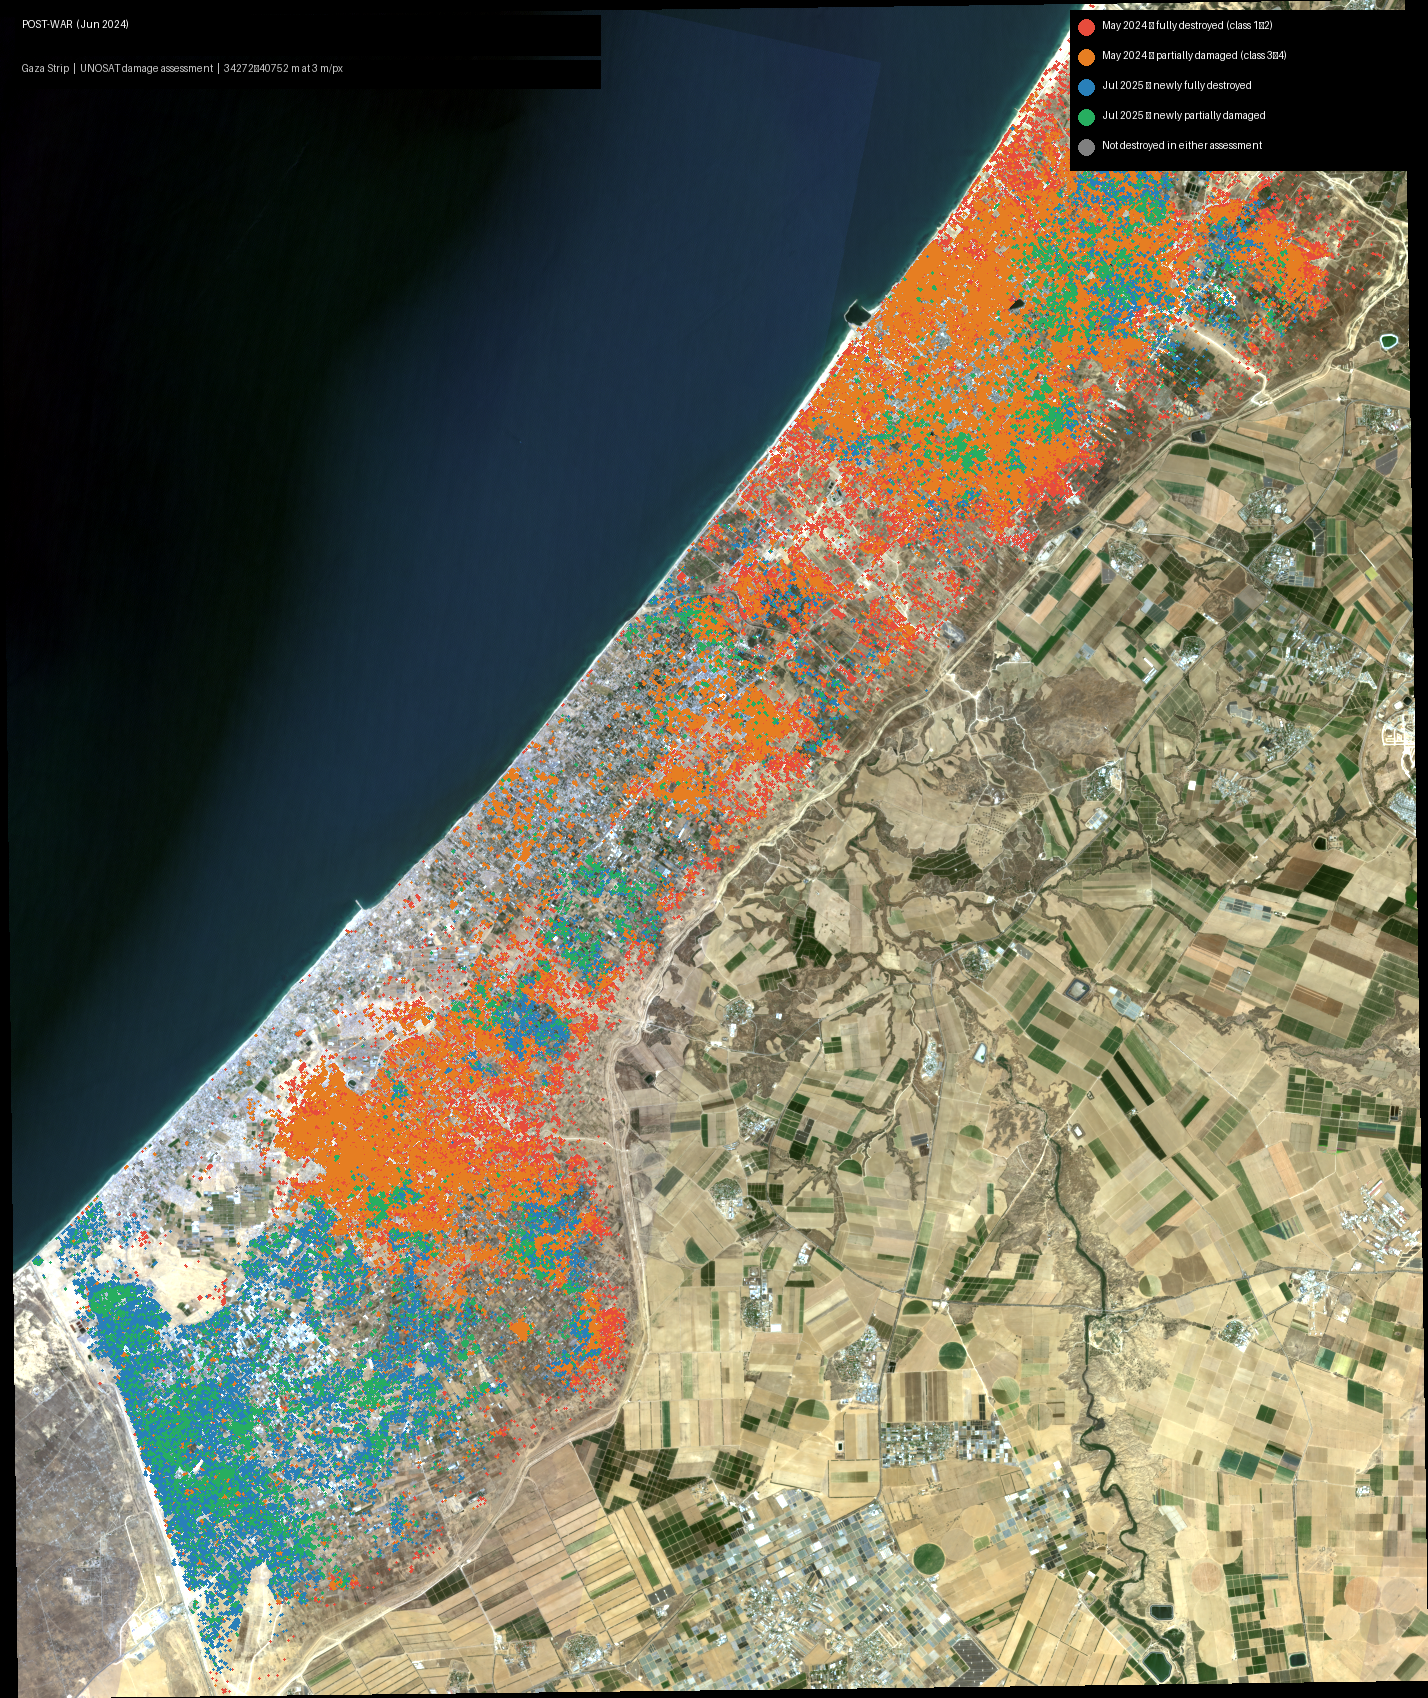

In [ ]:
# ONE full-Gaza map — paste as a single cell in Colab
from PIL import Image, ImageDraw, ImageFont
import numpy as np, rasterio, geopandas as gpd, os

BASE    = '/content/drive/MyDrive/Colab Notebooks/War_Damage'
PS_TIF  = f'{BASE}/rasters/gaza_20240503_ps_pre12m_forward1m_3m.tif'
JUL_GDB = f'{BASE}/UNOSAT_GazaStrip_CDA_08July2025.gdb'

PERIOD  = 'post'   # 'pre' or 'post'
SCALE   = 8        # read at 1/SCALE resolution; 8 → ~1430×1700 px ≈ 3 m×8 = 24 m/px
DOT_R   = 1       # dot radius in output pixels

FULLY  = {1, 2};  PARTLY = {3, 4}
COL = {'grey':'#808080','red':'#E74C3C','orange':'#E67E22',
       'blue':'#2980B9','green':'#27AE60'}

def hex_rgb(h):
    h = h.lstrip('#')
    return tuple(int(h[i:i+2],16) for i in (0,2,4))

# ── read raster at reduced resolution ────────────────────────────────────────
print('Reading imagery …')
bands = [3,2,1] if PERIOD=='pre' else [7,6,5]
with rasterio.open(PS_TIF) as src:
    H0,W0 = src.height, src.width
    H,W   = H0//SCALE, W0//SCALE
    arr   = src.read(bands, out_shape=(3,H,W),
                     resampling=rasterio.enums.Resampling.average).astype('float32')
    # pixel coordinate transform at reduced resolution
    inv   = ~src.transform
    scale_a = inv.a / SCALE;  scale_e = inv.e / SCALE
    scale_c = inv.c;           scale_f = inv.f
    raster_crs = src.crs

# stretch to uint8
def stretch(a, pct=(1,99)):
    out = np.zeros((*a.shape[1:],3), np.uint8)
    for k in range(3):
        ch = a[k]; v = ch[ch>0]
        lo,hi = (np.percentile(v,pct) if v.size else (0,1))
        out[...,k] = np.clip((ch-lo)/max(hi-lo,1e-6)*255,0,255)
    return out

print(f'Output size: {W}×{H} px  ({W*3*SCALE/1000:.1f}×{H*3*SCALE/1000:.1f} km)')
img  = Image.fromarray(stretch(arr), 'RGB')
draw = ImageDraw.Draw(img)

# ── load and colour UNOSAT points ────────────────────────────────────────────
print('Loading UNOSAT …')
jul = gpd.read_file(JUL_GDB, layer='Damage_Sites_GazaStrip_20250708')
jul = jul.to_crs('EPSG:4326').to_crs(raster_crs)
cx, cy = jul.geometry.x.values, jul.geometry.y.values

def colour(row):
    gm = row['grp_may']; gj = row['grp_jul']
    if gm=='fully':  return 'red'
    if gm=='partly': return 'orange'
    if gj=='fully':  return 'blue'
    if gj=='partly': return 'green'
    return 'grey'

def grp(c):
    if c in FULLY:  return 'fully'
    if c in PARTLY: return 'partly'
    return 'none'

jul['grp_may'] = jul['Main_Damage_Site_Class_7'].map(grp)
jul['grp_jul'] = jul['Main_Damage_Site_Class_13'].map(grp)
jul['color']   = jul.apply(colour, axis=1)

# pixel coords at reduced resolution
px = np.round(inv.a * cx / SCALE + inv.c / SCALE
              + (1-1/SCALE) * 0).astype(int)   # simple: just divide by SCALE
# correct formula: pixel coord in full raster divided by SCALE
px_col = np.round((inv.a*cx + inv.b*cy + inv.c) / SCALE).astype(int)
px_row = np.round((inv.d*cx + inv.e*cy + inv.f) / SCALE).astype(int)

inside = (px_col>=0)&(px_col<W)&(px_row>=0)&(px_row<H)
print(f'{inside.sum():,} of {len(jul):,} points inside image')

# draw dots — group by colour for speed
r = DOT_R
for col_key, col_hex in COL.items():
    m = (jul['color'].values == col_key) & inside
    rgb = hex_rgb(col_hex)
    for pc,pr in zip(px_col[m], px_row[m]):
        draw.ellipse([pc-r, pr-r, pc+r, pr+r], fill=rgb)
    print(f'  {col_key:8s}: {m.sum():>7,} dots')

# ── annotations ───────────────────────────────────────────────────────────────
try:
    fL = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf', 28)
    fS = ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', 18)
except:
    fL = fS = ImageFont.load_default()

label = 'PRE-WAR  (Oct 2022–Oct 2023)' if PERIOD=='pre' else 'POST-WAR  (Jun 2024)'
draw.rectangle([15,15,600,55], fill=(0,0,0))
draw.text((22,18), label, fill=(255,255,255), font=fL)
draw.rectangle([15,60,600,88], fill=(0,0,0))
draw.text((22,62), f'Gaza Strip  |  UNOSAT damage assessment  |  {W*3*SCALE}×{H*3*SCALE} m at 3 m/px',
          fill=(200,200,200), font=fS)

legend = [('red','May 2024 — fully destroyed (class 1–2)'),
          ('orange','May 2024 — partially damaged (class 3–4)'),
          ('blue','Jul 2025 — newly fully destroyed'),
          ('green','Jul 2025 — newly partially damaged'),
          ('grey','Not destroyed in either assessment')]
lx,ly = W-350, 15
draw.rectangle([lx-8,ly-5,W-8,ly+len(legend)*30+5], fill=(0,0,0))
for i,(ck,lbl) in enumerate(legend):
    y = ly+i*30; rr=8
    draw.ellipse([lx,y+4,lx+2*rr,y+4+2*rr], fill=hex_rgb(COL[ck]))
    draw.text((lx+2*rr+8,y+4), lbl, fill=(255,255,255), font=fS)

# ── save ──────────────────────────────────────────────────────────────────────
out = f'{BASE}/gaza_full_{PERIOD}.jpg'
img.convert('RGB').save(out, quality=92)
print(f'\nSaved → {out}  ({os.path.getsize(out)/1e6:.1f} MB)')
img   # display in Colab

In [ ]:
# Impact analysis — four subsets of the May 2024 UNOSAT labels
# Paste as one cell.
#
# Base : all footprints, positive = any damage in May 2024
# A    : remove footprints undamaged in May but damaged in July
#        (future-damage cases: they look intact in May imagery but are
#         destroyed by July — keeping them mislabels true negatives)
# B    : all footprints, positive = fully/severely destroyed in May (class 1–2 only)
# A+B  : A subset, positive = fully/severely destroyed in May

import numpy as np, pandas as pd, geopandas as gpd
from scipy.spatial import cKDTree
from shapely.geometry import shape
import json, os

BASE    = '/content/drive/MyDrive/Colab Notebooks/War_Damage'
FP_CSV  = f'{BASE}/Gaza_20240503_1_footprints.csv'
JUL_GDB = f'{BASE}/UNOSAT_GazaStrip_CDA_08July2025.gdb'

# ── load footprints in UTM ────────────────────────────────────────────────────
print('Loading footprints …')
fp = pd.read_csv(FP_CSV, usecols=['.geo','class','area','max_change'])
fp = gpd.GeoDataFrame(fp.drop(columns='.geo'),
    geometry=[shape(json.loads(g)) for g in fp['.geo']], crs='EPSG:4326')
fp_m = fp.to_crs('EPSG:32636')           # UTM metres throughout
fp['x'] = fp_m.geometry.centroid.x       # UTM easting  (metres)
fp['y'] = fp_m.geometry.centroid.y       # UTM northing (metres)

# ── load 5-way labels for both assessments ───────────────────────────────────
print('Loading UNOSAT labels …')
jul = gpd.read_file(JUL_GDB, layer='Damage_Sites_GazaStrip_20250708',
                    columns=['geometry','Main_Damage_Site_Class_7',
                             'Main_Damage_Site_Class_13'])
ju_m = jul.to_crs('EPSG:4326').to_crs('EPSG:32636')

joined = gpd.sjoin_nearest(
    fp_m[['geometry']].assign(idx=np.arange(len(fp))),
    ju_m[['geometry','Main_Damage_Site_Class_7','Main_Damage_Site_Class_13']],
    how='left').drop_duplicates('idx').set_index('idx').sort_index()

fp['cls_may'] = joined['Main_Damage_Site_Class_7'].values
fp['cls_jul'] = joined['Main_Damage_Site_Class_13'].values

FULLY={1,2}; PARTLY={3,4}
def grp(c):
    if pd.isna(c): return 'none'
    c=int(c)
    if c in FULLY: return 'fully'
    if c in PARTLY: return 'partly'
    return 'none'

fp['grp_may'] = fp['cls_may'].map(grp)
fp['grp_jul'] = fp['cls_jul'].map(grp)

dmg_may = fp['grp_may'].isin(['fully','partly'])
dmg_jul = fp['grp_jul'].isin(['fully','partly'])
remove_A = (~dmg_may) & dmg_jul    # undamaged May, damaged July → remove

# ── print class distribution ──────────────────────────────────────────────────
print('\nMay 2024 class distribution:')
cls_lbl={1:'1-Destroyed',2:'2-Severely',3:'3-Moderately',
         4:'4-Possibly',11:'11-No damage',6:'6-N/A'}
for c,n in fp['cls_may'].value_counts(dropna=False).sort_index().items():
    lbl=cls_lbl.get(int(c) if pd.notna(c) else -1, 'NaN/other')
    print(f'  {lbl:20s} {n:>8,}  ({100*n/len(fp):.1f}%)')

print(f'\nA removes {remove_A.sum():,} footprints  '
      f'(undamaged May, but damaged by July)')
print(f'  After A: {(~remove_A).sum():,} = '
      f'{(~remove_A & dmg_may).sum():,} damaged-May + '
      f'{(~remove_A & ~dmg_may).sum():,} truly intact')

# ── four subsets ──────────────────────────────────────────────────────────────
def make_subset(apply_A=False, fully_only=False):
    mask = ~remove_A if apply_A else pd.Series(True, index=fp.index)
    d = fp[mask].copy()
    if fully_only:
        d['label'] = (d['grp_may'] == 'fully').astype(int)
    else:
        d['label'] = d['grp_may'].isin(['fully','partly']).astype(int)
    return d

SUBSETS = {
    'Base':  make_subset(False, False),
    'A':     make_subset(True,  False),
    'B':     make_subset(False, True),
    'A+B':   make_subset(True,  True),
}

# ── metrics (all distances in metres via UTM) ─────────────────────────────────
LAT_BANDS = [
    ('North Gaza',     3488000, 9e9),
    ('Gaza City',      3478000, 3488000),
    ('Deir el-Balah',  3468000, 3478000),
    ('Khan Younis',    3458000, 3468000),
    ('Rafah',         -9e9,     3458000),
]

def geo_breakdown(d):
    rows=[]
    for name,lo,hi in LAT_BANDS:
        sub=d[(d['y']>=lo)&(d['y']<hi)]
        n=len(sub); p=sub['label'].sum() if n else 0
        rows.append({'region':name,'n':n,'n_pos':p,
                     'pct_pos':100*p/n if n else np.nan})
    return pd.DataFrame(rows).set_index('region')

def nn_stats_pos(d):
    """Median & mean nearest-neighbour distance (m) among positive labels."""
    pos=d[d['label']==1]
    if len(pos)<2: return np.nan, np.nan
    coords=pos[['x','y']].values
    tree=cKDTree(coords)
    dists,_=tree.query(coords, k=2)
    nn=dists[:,1]
    return float(np.median(nn)), float(np.mean(nn))

def moran_i(d, cell_m=1000):
    """Global Moran's I on a regular 1 km grid."""
    gx=((d['x']-d['x'].min())/cell_m).astype(int)
    gy=((d['y']-d['y'].min())/cell_m).astype(int)
    cells=pd.DataFrame({'gx':gx.values,'gy':gy.values,'lbl':d['label'].values})
    g=cells.groupby(['gx','gy'])['lbl'].mean().reset_index()
    if len(g)<4: return np.nan
    z=g['lbl'].values - g['lbl'].mean()
    coords=g[['gx','gy']].values.astype(float)
    tree=cKDTree(coords)
    _,idx=tree.query(coords, k=min(5,len(coords)))
    wz=np.array([z[idx[i,1:]].mean() for i in range(len(z))])
    zv=(z**2).sum()
    if zv==0: return 0.0
    return float(len(z)*(z*wz).sum()/(zv*4))

def grid_stats(d, cell_m=500):
    """Fraction of 500 m grid cells that contain at least one positive."""
    gx=((d['x']-d['x'].min())/cell_m).astype(int)
    gy=((d['y']-d['y'].min())/cell_m).astype(int)
    cells=pd.DataFrame({'gx':gx.values,'gy':gy.values,'lbl':d['label'].values})
    g=cells.groupby(['gx','gy'])['lbl'].max()
    return int(len(g)), int(g.sum()), float(100*g.mean())

# ── compute & display ─────────────────────────────────────────────────────────
print('\nComputing (Moran\'s I takes ~30 s for 228k points) …')
rows={}
for name,d in SUBSETS.items():
    nn_med, nn_mean = nn_stats_pos(d)
    n_cells, n_pos_cells, pct_cells = grid_stats(d)
    mi = moran_i(d)
    geo = geo_breakdown(d)
    def gv(r,col):
        try:
            v=geo.loc[r,col]
            return f'{v:.1f}' if not np.isnan(v) else '—'
        except: return '—'
    def gn(r):
        try: return f'{int(geo.loc[r,"n"]):,}'
        except: return '—'

    rows[name]={
        '── Labels ──────────────': '',
        'N labels':                 f'{len(d):,}',
        'N positive':               f'{d["label"].sum():,}',
        'Prevalence (%)':           f'{100*d["label"].mean():.1f}',
        '── Clustering ───────────': '',
        'Moran\'s I (1 km grid)':  f'{mi:.3f}',
        'NN median dist, pos (m)':  f'{nn_med:.0f}' if not np.isnan(nn_med) else '—',
        'NN mean dist, pos (m)':    f'{nn_mean:.0f}' if not np.isnan(nn_mean) else '—',
        '500m cells w/ data':       f'{n_cells:,}',
        '500m cells w/ positive':   f'{n_pos_cells:,}',
        '500m cells positive (%)':  f'{pct_cells:.1f}',
        '── Regional (% positive)': '',
        'North Gaza':               gv('North Gaza','pct_pos'),
        'Gaza City':                gv('Gaza City','pct_pos'),
        'Deir el-Balah':            gv('Deir el-Balah','pct_pos'),
        'Khan Younis':              gv('Khan Younis','pct_pos'),
        'Rafah':                    gv('Rafah','pct_pos'),
        '── Regional (n labels) ─': '',
        'North Gaza n':             gn('North Gaza'),
        'Gaza City n':              gn('Gaza City'),
        'Deir el-Balah n':          gn('Deir el-Balah'),
        'Khan Younis n':            gn('Khan Younis'),
        'Rafah n':                  gn('Rafah'),
    }

result=pd.DataFrame(rows)
result.index.name='Metric'
print('\n'+'='*75)
print('METRIC COMPARISON — MAY 2024 UNOSAT ASSESSMENT, FOUR SUBSETS')
print('='*75)
with pd.option_context('display.max_colwidth',None,'display.width',100):
    print(result.to_string())
print('='*75)
print('\nBase : all footprints | positive = any May 2024 damage (class 1–4)')
print('A    : remove footprints undamaged in May but damaged by July 2025')
print('B    : all footprints | positive = class 1–2 only (destroyed/severely)')
print('A+B  : A subset + B labelling')
print('Moran I > 0 = spatially clustered | NN dist = median gap between positive pairs')

result.to_csv(f'{BASE}/subset_metrics.csv')
print(f'\nSaved → {BASE}/subset_metrics.csv')

Loading footprints …
Loading UNOSAT labels …

May 2024 class distribution:
  1-Destroyed            36,912  (16.1%)
  2-Severely             19,164  (8.4%)
  3-Moderately           61,964  (27.1%)
  4-Possibly             40,260  (17.6%)
  6-N/A                       8  (0.0%)
  11-No damage            6,333  (2.8%)
  NaN/other              64,089  (28.0%)

A removes 64,089 footprints  (undamaged May, but damaged by July)
  After A: 164,641 = 158,300 damaged-May + 6,341 truly intact

Computing (Moran's I takes ~30 s for 228k points) …

METRIC COMPARISON — MAY 2024 UNOSAT ASSESSMENT, FOUR SUBSETS
                              Base        A        B      A+B
Metric                                                       
── Labels ──────────────                                     
N labels                   228,730  164,641  228,730  164,641
N positive                 158,300  158,300   56,076   56,076
Prevalence (%)                69.2     96.1     24.5     34.1
── Clustering ───────────

In [ ]:
# Impact analysis — five subsets of the May 2024 UNOSAT labels
# Paste as one cell.
#
# Base : all footprints | positive = any May damage (class 1–4)
# A    : remove footprints undamaged in May but damaged by July (any class)
# B    : all footprints | positive = class 1–2 only (fully/severely destroyed)
# A+B  : A subset + B labelling
# C    : remove footprints NOT fully/severely damaged in May (class 1–2)
#        but ARE fully/severely damaged in July (class 1–2)
#        positive = class 1–2 in May; class 3–4 count as negative
#
# C logic: we define "damaged" strictly as class 1–2 only.
# We then remove the cases that are NOT damaged under this definition in May
# but ARE damaged under this definition in July — same as A but using the
# strict class 1–2 criterion for both the removal rule and the label.

import numpy as np, pandas as pd, geopandas as gpd
from scipy.spatial import cKDTree
from shapely.geometry import shape
import json, os

BASE    = '/content/drive/MyDrive/Colab Notebooks/War_Damage'
FP_CSV  = f'{BASE}/Gaza_20240503_1_footprints.csv'
JUL_GDB = f'{BASE}/UNOSAT_GazaStrip_CDA_08July2025.gdb'

# ── load ─────────────────────────────────────────────────────────────────────
print('Loading footprints …')
fp = pd.read_csv(FP_CSV, usecols=['.geo','class','area','max_change'])
fp = gpd.GeoDataFrame(fp.drop(columns='.geo'),
    geometry=[shape(json.loads(g)) for g in fp['.geo']], crs='EPSG:4326')
fp_m = fp.to_crs('EPSG:32636')
fp['x'] = fp_m.geometry.centroid.x
fp['y'] = fp_m.geometry.centroid.y

print('Loading UNOSAT labels …')
jul = gpd.read_file(JUL_GDB, layer='Damage_Sites_GazaStrip_20250708',
                    columns=['geometry','Main_Damage_Site_Class_7',
                             'Main_Damage_Site_Class_13'])
ju_m = jul.to_crs('EPSG:4326').to_crs('EPSG:32636')

joined = gpd.sjoin_nearest(
    fp_m[['geometry']].assign(idx=np.arange(len(fp))),
    ju_m[['geometry','Main_Damage_Site_Class_7','Main_Damage_Site_Class_13']],
    how='left').drop_duplicates('idx').set_index('idx').sort_index()

fp['cls_may'] = joined['Main_Damage_Site_Class_7'].values
fp['cls_jul'] = joined['Main_Damage_Site_Class_13'].values

FULLY={1,2}; PARTLY={3,4}
def grp(c):
    if pd.isna(c): return 'none'
    c=int(c)
    if c in FULLY: return 'fully'
    if c in PARTLY: return 'partly'
    return 'none'

fp['grp_may'] = fp['cls_may'].map(grp)
fp['grp_jul'] = fp['cls_jul'].map(grp)

dmg_may_any   = fp['grp_may'].isin(['fully','partly'])  # any damage May
dmg_jul_any   = fp['grp_jul'].isin(['fully','partly'])  # any damage Jul
fully_may     = fp['grp_may'] == 'fully'                # class 1–2 May
fully_jul     = fp['grp_jul'] == 'fully'                # class 1–2 Jul

remove_A = (~dmg_may_any) & dmg_jul_any   # not damaged May, damaged Jul (broad)
remove_C = (~fully_may)   & fully_jul     # not fully/severely May, but is in Jul

# ── class distribution ────────────────────────────────────────────────────────
print('\nMay 2024 class distribution:')
cls_lbl = {1:'1-Destroyed',2:'2-Severely',3:'3-Moderately',
           4:'4-Possibly',11:'11-No damage',6:'6-N/A'}
for c,n in fp['cls_may'].value_counts(dropna=False).sort_index().items():
    lbl = cls_lbl.get(int(c) if pd.notna(c) else -1, 'NaN/other')
    print(f'  {lbl:20s} {n:>8,}  ({100*n/len(fp):.1f}%)')

print(f'\nA removes: {remove_A.sum():,}  '
      f'(undamaged May [any class], damaged July [any class])')
print(f'C removes: {remove_C.sum():,}  '
      f'(not fully/severely May, but fully/severely July)')
print(f'  C - A overlap: {(remove_A & remove_C).sum():,}  '
      f'| C-only: {(remove_C & ~remove_A).sum():,}')

# ── five subsets ───────────────────────────────────────────────────────────────
def make_subset(apply_A=False, apply_C=False, fully_only=False):
    if apply_C:
        mask = ~remove_C
    elif apply_A:
        mask = ~remove_A
    else:
        mask = pd.Series(True, index=fp.index)
    d = fp[mask].copy()
    if fully_only or apply_C:
        d['label'] = (d['grp_may'] == 'fully').astype(int)
    else:
        d['label'] = d['grp_may'].isin(['fully','partly']).astype(int)
    return d

SUBSETS = {
    'Base': make_subset(),
    'A':    make_subset(apply_A=True),
    'B':    make_subset(fully_only=True),
    'A+B':  make_subset(apply_A=True, fully_only=True),
    'C':    make_subset(apply_C=True),
}

# ── metric functions ───────────────────────────────────────────────────────────
LAT_BANDS = [
    ('North Gaza',    3488000, 9e9),
    ('Gaza City',     3478000, 3488000),
    ('Deir el-Balah', 3468000, 3478000),
    ('Khan Younis',   3458000, 3468000),
    ('Rafah',        -9e9,     3458000),
]

def geo_breakdown(d):
    rows = []
    for name, lo, hi in LAT_BANDS:
        sub = d[(d['y']>=lo) & (d['y']<hi)]
        n = len(sub); p = sub['label'].sum() if n else 0
        rows.append({'region':name,'n':n,'n_pos':p,
                     'pct_pos':100*p/n if n else np.nan})
    return pd.DataFrame(rows).set_index('region')

def nn_stats(d):
    pos = d[d['label']==1]
    if len(pos) < 2: return np.nan, np.nan
    tree = cKDTree(pos[['x','y']].values)
    dists, _ = tree.query(pos[['x','y']].values, k=2)
    nn = dists[:,1]
    return float(np.median(nn)), float(np.mean(nn))

def moran_i(d, cell_m=1000):
    gx = ((d['x']-d['x'].min())/cell_m).astype(int)
    gy = ((d['y']-d['y'].min())/cell_m).astype(int)
    cells = pd.DataFrame({'gx':gx.values,'gy':gy.values,'lbl':d['label'].values})
    g = cells.groupby(['gx','gy'])['lbl'].mean().reset_index()
    if len(g) < 4: return np.nan
    z = g['lbl'].values - g['lbl'].mean()
    coords = g[['gx','gy']].values.astype(float)
    tree = cKDTree(coords)
    _, idx = tree.query(coords, k=min(5,len(coords)))
    wz = np.array([z[idx[i,1:]].mean() for i in range(len(z))])
    zv = (z**2).sum()
    return float(len(z)*(z*wz).sum()/(zv*4)) if zv > 0 else 0.0

def grid_stats(d, cell_m=500):
    gx = ((d['x']-d['x'].min())/cell_m).astype(int)
    gy = ((d['y']-d['y'].min())/cell_m).astype(int)
    cells = pd.DataFrame({'gx':gx.values,'gy':gy.values,'lbl':d['label'].values})
    g = cells.groupby(['gx','gy'])['lbl'].max()
    return int(len(g)), int(g.sum()), float(100*g.mean())

# ── compute ────────────────────────────────────────────────────────────────────
print('\nComputing metrics …')
rows = {}
for name, d in SUBSETS.items():
    nn_med, nn_mean = nn_stats(d)
    n_cells, n_pos_cells, pct_cells = grid_stats(d)
    mi = moran_i(d)
    geo = geo_breakdown(d)
    def gv(r):
        try: v=geo.loc[r,'pct_pos']; return f'{v:.1f}' if not np.isnan(v) else '—'
        except: return '—'
    def gn(r):
        try: return f'{int(geo.loc[r,"n"]):,}'
        except: return '—'

    rows[name] = {
        '─ Labels ───────────────': '',
        'N labels':                f'{len(d):,}',
        'N positive':              f'{d["label"].sum():,}',
        'Prevalence (%)':          f'{100*d["label"].mean():.1f}',
        '─ Clustering ────────────': '',
        "Moran's I (1km grid)":    f'{mi:.3f}',
        'NN median dist pos (m)':  f'{nn_med:.0f}' if not np.isnan(nn_med) else '—',
        'NN mean dist pos (m)':    f'{nn_mean:.0f}' if not np.isnan(nn_mean) else '—',
        '500m cells w/ data':      f'{n_cells:,}',
        '500m cells w/ positive':  f'{n_pos_cells:,}',
        '500m cells positive (%)': f'{pct_cells:.1f}',
        '─ Regional % positive ──': '',
        'North Gaza':              gv('North Gaza'),
        'Gaza City':               gv('Gaza City'),
        'Deir el-Balah':           gv('Deir el-Balah'),
        'Khan Younis':             gv('Khan Younis'),
        'Rafah':                   gv('Rafah'),
        '─ Regional n labels ────': '',
        'North Gaza n':            gn('North Gaza'),
        'Gaza City n':             gn('Gaza City'),
        'Deir el-Balah n':         gn('Deir el-Balah'),
        'Khan Younis n':           gn('Khan Younis'),
        'Rafah n':                 gn('Rafah'),
    }

result = pd.DataFrame(rows)
result.index.name = 'Metric'

print('\n' + '='*90)
print('METRIC COMPARISON — MAY 2024 UNOSAT ASSESSMENT, FIVE SUBSETS')
print('='*90)
with pd.option_context('display.max_colwidth', None, 'display.width', 110):
    print(result.to_string())
print('='*90)

print("""
Subset definitions:
  Base : all 228,730 footprints | positive = any May damage (class 1–4)
  A    : remove buildings undamaged in May (any class) but damaged by July (any class)
         keeps: damaged-May + truly intact (not damaged in either)
  B    : all footprints | positive = class 1–2 only (destroyed / severely damaged)
         class 3–4 treated as negative
  A+B  : A removal rule + B label definition
  C    : remove buildings not fully/severely damaged in May (class 1–2)
         but fully/severely damaged by July (class 1–2)
         keeps: fully/severely May + class 3–4 May + truly intact
         positive = class 1–2 in May; class 3–4 count as negative
         (strictest subset: both the removal and the label use the class 1–2 threshold)

Moran's I > 0 = spatially clustered  |  NN dist = median gap between positive building pairs
""")

out = f'{BASE}/subset_metrics.csv'
result.to_csv(out)
print(f'Saved → {out}')

Loading footprints …
Loading UNOSAT labels …

May 2024 class distribution:
  1-Destroyed            36,912  (16.1%)
  2-Severely             19,164  (8.4%)
  3-Moderately           61,964  (27.1%)
  4-Possibly             40,260  (17.6%)
  6-N/A                       8  (0.0%)
  11-No damage            6,333  (2.8%)
  NaN/other              64,089  (28.0%)

A removes: 64,089  (undamaged May [any class], damaged July [any class])
C removes: 70,513  (not fully/severely May, but fully/severely July)
  C - A overlap: 43,687  | C-only: 26,826

Computing metrics …

METRIC COMPARISON — MAY 2024 UNOSAT ASSESSMENT, FIVE SUBSETS
                              Base        A        B      A+B        C
Metric                                                                
─ Labels ───────────────                                              
N labels                   228,730  164,641  228,730  164,641  158,217
N positive                 158,300  158,300   56,076   56,076   56,076
Prevalence (%)    